In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import os
import json
import pathlib
from tensorflow.keras.layers import InputLayer, Conv2D, Dense, MaxPool2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy, FalseNegatives, FalsePositives, F1Score #, RootMeanSquaredError

# Data
- [load data](https://www.tensorflow.org/datasets/api_docs/python/tfds/load)

In [44]:
# dataset, dataset_info = tfds.load('malaria', with_info = True, as_supervised = True, shuffle_files  =True, split = ['train', 'test'])

In [3]:
image_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/checkthat_mm"

In [4]:
train_path = os.path.join(image_path, "train")
test_path = os.path.join(image_path, "test")
dev_path = os.path.join(image_path, 'dev')
dev_test_path = os.path.join(image_path, 'dev_test')

In [34]:
# download and extract from url
# train_yes_url = os.path.join(train_path,'train/train_yes')
# print(train_yes_url)
# archive = tf.keras.utils.get_file(origin=train_yes_url)
# data_dir = pathlib.Path(archive).with_suffix('')

/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/checkthat_mm/train/train/train_yes


In [5]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(train_path)

Found 2356 files belonging to 2 classes.


In [6]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(test_path)


Found 736 files belonging to 2 classes.


In [8]:
dev_dataset = tf.keras.preprocessing.image_dataset_from_directory(dev_path)
dev_dataset

Found 271 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
dev_test_dataset = tf.keras.preprocessing.image_dataset_from_directory(dev_test_path)

Found 548 files belonging to 2 classes.


In [10]:
for x, y in train_dataset.take(1):
  print(x)
  print(y)

tf.Tensor(
[[[[ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   ...
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]]

  [[ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   ...
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]]

  [[ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   [ 16.          16.          16.        ]
   ...
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]
   [ 18.          18.          18.        ]]

  ...

  [[  7.1225586    7.1225586    7.1225586 ]
   [  0.80493164   0.80493164   0.80493164]
   [  2.21875      2.21875      2.21875   ]
   ...
   [  1.5859375    1.585

In [11]:
print(train_dataset.class_names)
print(test_dataset.class_names)
print(dev_dataset.class_names)
print(dev_test_dataset.class_names)

['train_no', 'train_yes']
['test_no', 'test_yes']
['dev_no', 'dev_yes']
['dev_test_no', 'dev_test_yes']


## visualize the data

In [12]:
plt.figure(figsize=(20, 40))
for images, labels in train_dataset.take(1):
  for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_dataset.class_names[labels[i]]) # before resizing
    # plt.title(labels[i]) # afetr resizing
    plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

In [13]:
for image_batch, labels_batch in train_dataset:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 256, 256, 3)
(32,)


## Data Processing
- Standerdize
  - X = (x - mean)/SD [ **if most of the pixels revolve with particula mean value**]

- Normalize
  - X = (x - x_min) / (x_max - x_min) [ **if pixel values are mostly different from one and another** ]

- [Image resize](https://www.tensorflow.org/api_docs/python/tf/image/resize)

In [14]:
IM_SIZE = 224
def resize_rescaling(image, label):
  return tf.image.resize(image, (IM_SIZE, IM_SIZE))/255.0, tf.expand_dims(label, axis = -1)

In [139]:
# def rescaling(image, label):
#   normalization_layer = tf.keras.layers.Rescaling(1./255)
#   normalization_ds = train_dataset.map(lambda image, label: (normalization_layer(image), label))
#   return normalization_ds
  #image_batch, labels_batch = next(iter(normalization_ds))

In [15]:
train_dataset = train_dataset.map(resize_rescaling)

In [16]:
train_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>

In [104]:
# normalization = tf.keras.layers.Rescaling(1./2555)
# normalization_ds = train_dataset.map(lambda image, label: (normalization(image), label))
# image_batch, labels_batch = next(iter(normalization_ds))

# first_image = image[4]
# print(np.min(first_image), np.max(first_image))
# https://www.tensorflow.org/tutorials/load_data/images

In [140]:
# train_dataset = train_dataset.map(rescaling)

In [17]:
train_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>

In [18]:
train_dataset = train_dataset.shuffle(buffer_size=8, reshuffle_each_iteration=True).prefetch(tf.data.AUTOTUNE)

In [19]:
dev_dataset = dev_dataset.map(resize_rescaling).shuffle(buffer_size = 8, reshuffle_each_iteration = True).prefetch(tf.data.AUTOTUNE)

In [20]:
dev_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>

In [21]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>

In [23]:
test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [24]:
test_dataset = test_dataset.map(resize_rescaling).shuffle(buffer_size = 8, reshuffle_each_iteration = True).prefetch(tf.data.AUTOTUNE)

In [25]:
test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))>

In [22]:
for image, label in train_dataset.take(1):
  print(image, label)
  # print(label)

tf.Tensor(
[[[[0.7130517  0.71697325 0.7248164 ]
   [0.71134627 0.71526784 0.723111  ]
   [0.70716524 0.7110868  0.71892995]
   ...
   [0.66898954 0.6768327  0.6729111 ]
   [0.6710625  0.67890567 0.6749841 ]
   [0.6727201  0.6805632  0.67664164]]

  [[0.7015361  0.7054577  0.7133008 ]
   [0.70238787 0.70630944 0.7141526 ]
   [0.70171267 0.70563424 0.7134774 ]
   ...
   [0.64306486 0.650908   0.6469864 ]
   [0.6422544  0.65009755 0.646176  ]
   [0.64482075 0.6526639  0.6487423 ]]

  [[0.68327576 0.6871973  0.69504046]
   [0.6828597  0.6867813  0.6946244 ]
   [0.68447536 0.68839693 0.69624007]
   ...
   [0.61993927 0.6277824  0.62386084]
   [0.61900276 0.6268459  0.6229243 ]
   [0.6203866  0.62822974 0.62430817]]

  ...

  [[0.72741854 0.70881176 0.697058  ]
   [0.72543985 0.7061203  0.6946042 ]
   [0.7229551  0.7029767  0.6916802 ]
   ...
   [0.7282207  0.69684815 0.689005  ]
   [0.7205869  0.68921435 0.6813712 ]
   [0.71557236 0.6841998  0.6763567 ]]

  [[0.7458327  0.72965074 0.717886

In [170]:
for x, y in train_dataset.take(1):
    print(np.min(x))
    print(np.max(x))


0.0
1.0


In [40]:
train_dataset
# <_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
# <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None), dtype=tf.int32, name=None))>

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

#Modeling

- Without padding and stride
  - width_out = windth_input - filter_size + 1
  - height_out = height_input - filter_size + 1
- If the information is also in the edge of the imagem, padding is important.

- with padding and stride
  - width_out = (width_in - filter_size + 2 * padding)/stride + 1

  - height_out = (height_in - filter_size + 2 * padding)/stride + 1

- padding automatically calculated in tensorflow.

[CNNEXPLAINER](https://poloclub.github.io/cnn-explainer/)

[IMAGEKERNELS](https://setosa.io/ev/image-kernels/)

- CNN
  - [LeNet](https://en.wikipedia.org/wiki/LeNet)

- 7:41:00




- [@CNN architecture](https://cs231n.github.io/convolutional-networks/)

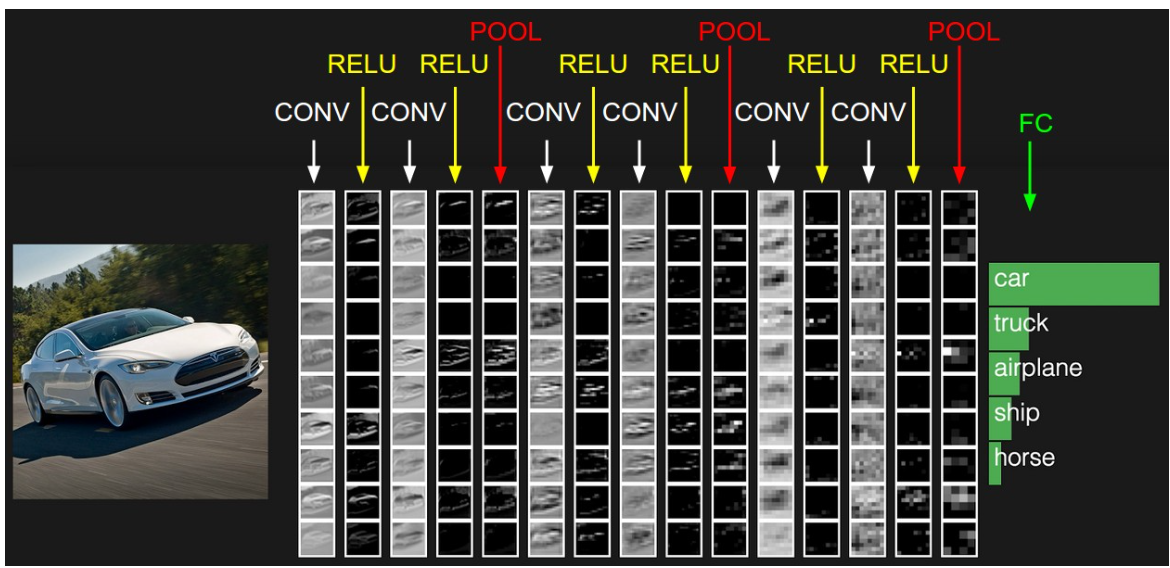

- first layer - feature extraction
- second layer - classification
- [convnet demo](https://cs.stanford.edu/people/karpathy/convnetjs/demo/mnist.html)

- Layers
  - [Input Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/InputLayer)

  - [CONV2D Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

    - [Stride](https://deepai.org/machine-learning-glossary-and-terms/stride)
    - [dilation_rate](https://github.com/vdumoulin/conv_arithmetic)

  - [MaxPOOL2D Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D)

  - [Flatten Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten)

  - [Dense Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)

- [Transformers](https://poloclub.github.io/transformer-explainer/)

- [LeNet](https://en.wikipedia.org/wiki/LeNet)

In [17]:
lenet_model = tf.keras.Sequential([
    InputLayer(shape = (IM_SIZE, IM_SIZE, 3)),

    Conv2D(filters = 6, kernel_size = 5, strides=(1, 1), padding = 'valid', activation = "sigmoid"),
    MaxPool2D(pool_size=2, strides=2),

    Conv2D(filters = 16, kernel_size = 5, strides=(1, 1), padding = 'valid', activation = "sigmoid"),
    MaxPool2D(pool_size=2, strides=2),

    Flatten(),


    Dense(100, activation="sigmoid"),
    Dense(10, activation = "sigmoid"),
    Dense(1, activation = "sigmoid"),
])
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 44944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,494,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,498,393 (17.16 MB)

 Trainable params: 4,498,393 (17.16 MB)

 Non-trainable params: 0 (0.00 B)

- [optimizer - Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam)

In [18]:
lenet_model.compile(
    optimizer = Adam(learning_rate=0.1),
    loss = BinaryCrossentropy(),
    metrics = [BinaryAccuracy , F1Score]
)

# Error Sanctioning

 - [Loss Function - Binary Cross Entropy](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html#cross-entropy)

 - [tf.keras.losses.BinaryCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy)
    - from_logits = True [assure the output will be always 0 or 1]

In [32]:
y_true = [0,1,0,0,0,1]
y_pred = [0.6, 0.94, 0.5, 0.7, 0.2, 0.68]

bce = tf.keras.losses.BinaryCrossentropy(from_logits = False)
bce(y_true, y_pred)
# numpy=0.7754186987876892 logits = True
# umpy=0.5806820392608643 logits = false


<tf.Tensor: shape=(), dtype=float32, numpy=0.5806820392608643>

# Training and optimization

In [47]:
for x, y in train_dataset.take(1):
  print(x.shape)
  print(y.shape)

(32, 224, 224, 3)
(32,)


In [ ]:
lenet_model.fit(train_dataset, validation_data=dev_dataset, epochs = 100)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - binary_accuracy: 0.6520 - f1_score: 0.5164 - loss: 0.6608 - val_binary_accuracy: 0.6790 - val_f1_score: 0.4860 - val_loss: 0.6499
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 342ms/step - binary_accuracy: 0.6520 - f1_score: 0.5164 - loss: 0.6561 - val_binary_accuracy: 0.6790 - val_f1_score: 0.4860 - val_loss: 0.6293
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 368ms/step - binary_accuracy: 0.6520 - f1_score: 0.5164 - loss: 0.6598 - val_binary_accuracy: 0.6790 - val_f1_score: 0.4860 - val_loss: 0.6304
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 391ms/step - binary_accuracy: 0.6520 - f1_score: 0.5164 - loss: 0.6527 - val_binary_accuracy: 0.6790 - val_f1_score: 0.4860 - val_loss: 0.6363
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 385ms/step - binary_accuracy: 0.6520 - f1_score: 0.5164 - loss: 0.6582 - val_binary_accuracy: 0.6790 - val_f1_score: 0.4860 - val_loss: 0.6761
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 382ms/step - binary_accuracy:

# Performance measurement

# Validating and testing

# Corrective measure